In [1]:
#Library
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

In [2]:
# --- PHASE 1: REPRODUCIBILITY AND HYPERPARAMETERS ---
SEED = 42
EPOCHS = 100
LEARNING_RATE = 1e-3
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)

In [14]:
# --- PHASE 2: DATA PREPROCESSING AND FEATURE ENGINEERING ---
df_housing = pd.read_csv("housing.csv")
df_housing.dropna(subset=['total_bedrooms'], inplace=True)

# Categorical Encoding (One-Hot Encoding for Ocean Proximity)
df_housing = pd.get_dummies(df_housing, columns=['ocean_proximity'])
column_mapping = {
    'ocean_proximity_<1H OCEAN': 'region_ocean_less_1h',
    'ocean_proximity_INLAND': 'region_inland',
    'ocean_proximity_ISLAND': 'region_island',
    'ocean_proximity_NEAR BAY': 'region_near_bay',
    'ocean_proximity_NEAR OCEAN': 'region_near_ocean'
}
df_housing.rename(columns=column_mapping, inplace=True)
df_housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,region_ocean_less_1h,region_inland,region_island,region_near_bay,region_near_ocean
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,False,False,False,True,False
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,False,False,False,True,False
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,False,False,False,True,False
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,False,False,False,True,False
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,False,False,False,True,False


In [4]:
# Feature-Target Separation
X = df_housing.drop("median_house_value", axis=1).values
y = df_housing["median_house_value"].values

# Data Splitting (70% Train, 15% Validation, 15% Test)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=SEED)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=SEED)

# Feature Scaling (Standardization)
scaler_X, scaler_y = StandardScaler(), StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_val_scaled = scaler_X.transform(X_val)
X_test_scaled = scaler_X.transform(X_test)

y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1))
y_val_scaled = scaler_y.transform(y_val.reshape(-1, 1))
y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1))

In [5]:
# Conversion to PyTorch Tensors
def to_tensor(data):
    return torch.tensor(data, dtype=torch.float32).to(DEVICE)

X_train_tensor = to_tensor(X_train_scaled)
y_train_tensor = to_tensor(y_train_scaled)
X_val_tensor = to_tensor(X_val_scaled)
y_val_tensor = to_tensor(y_val_scaled)
X_test_tensor = to_tensor(X_test_scaled)
y_test_tensor = to_tensor(y_test_scaled)

In [6]:
# --- PHASE 3: ARCHITECTURE DEFINITION ---
class DeepHousingMLP(nn.Module):
    """Multi-Layer Perceptron (MLP) Architecture for Regression."""
    def __init__(self, input_dim):
        super(DeepHousingMLP, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )

    def forward(self, x):
        return self.network(x)

def calculate_mape(y_true, y_pred):
    """Calculates Mean Absolute Percentage Error."""
    return np.mean(np.abs((y_true - y_pred) / (y_true + 1e-7))) * 100

In [8]:
# Loss Function Dictionary for Comparative Analysis
loss_criteria = {
    "MSE": nn.MSELoss(),
    "MAE (L1)": nn.L1Loss(),
    "Huber": nn.HuberLoss(delta=1.0),
    "Log-Cosh": lambda y_p, y_t: torch.mean(torch.log(torch.cosh(y_p - y_t)))
}

Executing Experiment: MSE Loss
Executing Experiment: MAE (L1) Loss
Executing Experiment: Huber Loss
Executing Experiment: Log-Cosh Loss


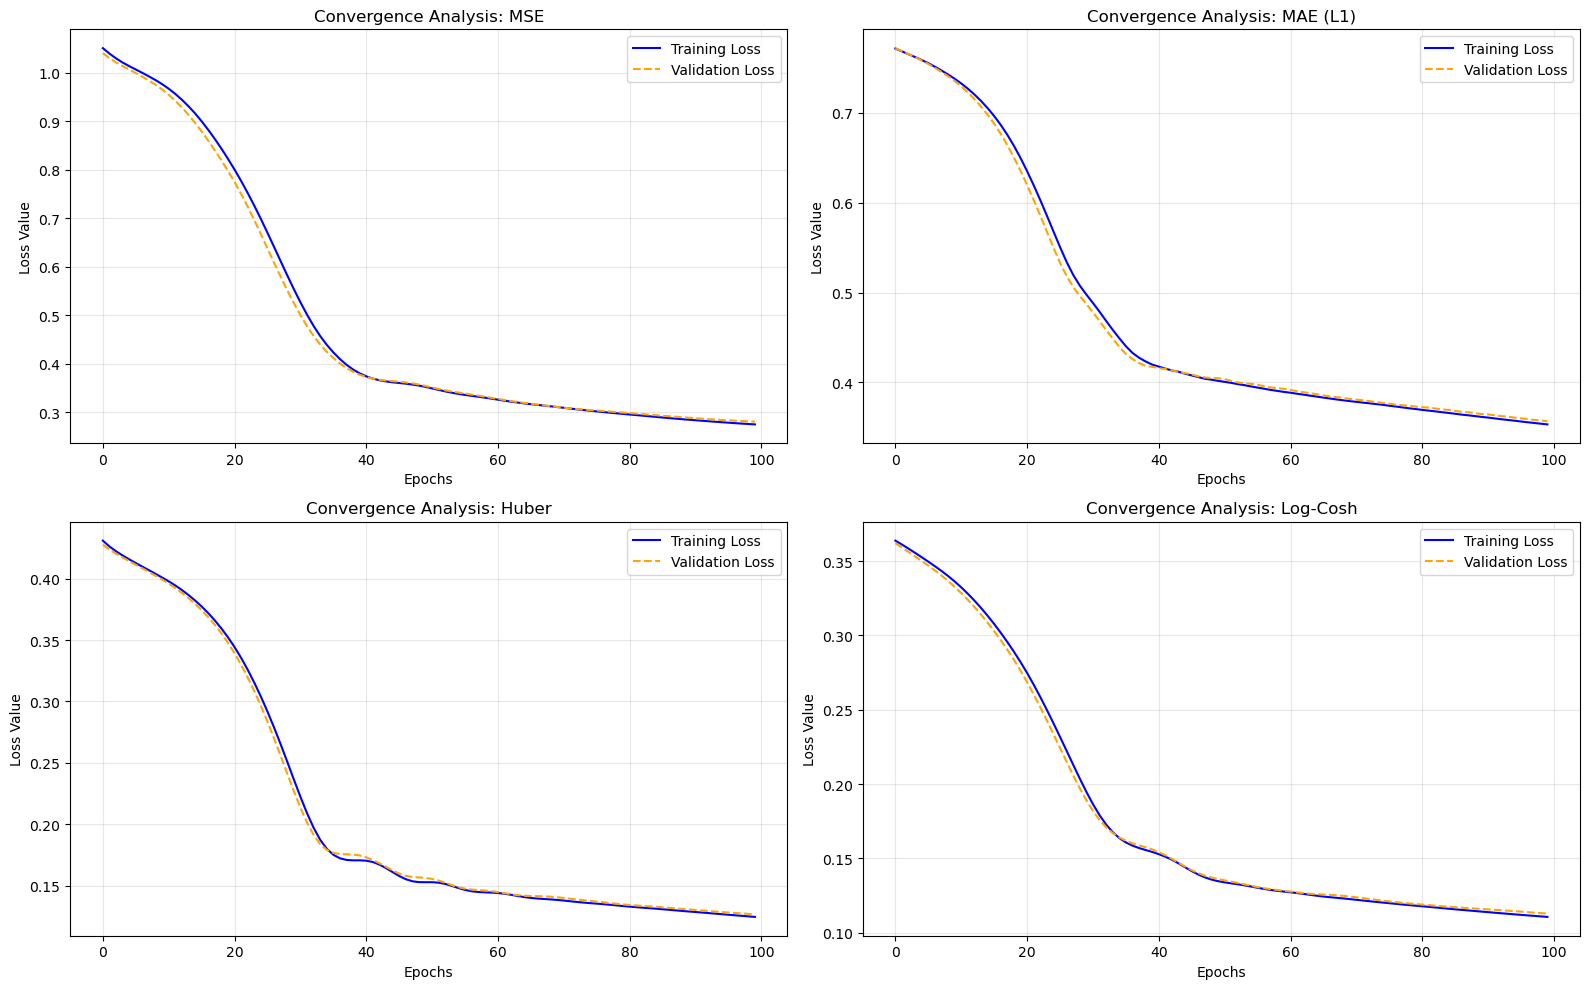

In [9]:
# --- PHASE 4: EXPERIMENTATION AND EVALUATION ---
results = {}
plt.figure(figsize=(16, 10))

for idx, (name, criterion) in enumerate(loss_criteria.items()):
    print(f"Executing Experiment: {name} Loss")
    model = DeepHousingMLP(X_train_tensor.shape[1]).to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    
    train_log, val_log = [], []
    
    for epoch in range(EPOCHS):
        # Training Phase
        model.train()
        optimizer.zero_grad()
        preds = model(X_train_tensor)
        loss = criterion(preds, y_train_tensor)
        loss.backward()
        optimizer.step()
        train_log.append(loss.item())
        
        # Validation Phase
        model.eval()
        with torch.no_grad():
            v_preds = model(X_val_tensor)
            v_loss = criterion(v_preds, y_val_tensor)
            val_log.append(v_loss.item())

    # Visualization of Convergence Curves
    plt.subplot(2, 2, idx + 1)
    plt.plot(train_log, label='Training Loss', color='blue')
    plt.plot(val_log, label='Validation Loss', color='orange', linestyle='--')
    plt.title(f'Convergence Analysis: {name}')
    plt.xlabel('Epochs')
    plt.ylabel('Loss Value')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Final Inference and Metric Extraction
    model.eval()
    with torch.no_grad():
        test_output = model(X_test_tensor).cpu().numpy()
        y_pred_final = scaler_y.inverse_transform(test_output)
        y_true_final = scaler_y.inverse_transform(y_test_tensor.cpu().numpy())
        
        results[name] = {
            "MAE ($)": mean_absolute_error(y_true_final, y_pred_final),
            "RMSE ($)": np.sqrt(mean_squared_error(y_true_final, y_pred_final)),
            "R2 Score": r2_score(y_true_final, y_pred_final),
            "MAPE (%)": calculate_mape(y_true_final, y_pred_final)
        }

plt.tight_layout()
plt.show()

In [13]:
# --- PHASE 5: STATISTICAL SUMMARY ---
df_results = pd.DataFrame(results).T
print(df_results.to_string())

               MAE ($)      RMSE ($)  R2 Score   MAPE (%)
MSE       42763.937500  60377.031924  0.726122  24.880291
MAE (L1)  40933.910156  60240.376094  0.727361  22.126524
Huber     42221.390625  60388.618795  0.726017  24.223362
Log-Cosh  41789.578125  59702.305751  0.732209  23.730345
